## Import Libraries

In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from IPython import display

## Inspect Data Structures

In [44]:
local_path = '../data/raw/pubmedqa_unlabeled_raw.csv'
dagshub_url = 'https://dagshub.com/THoangHa/Clinical-QA-System/raw/main/backend/AI/data/raw/pubmedqa_unlabeled_raw.csv'
if os.path.exists(local_path):
    print(f"Loading data from local path: {local_path}")
    df = pd.read_csv(local_path)
else:
    print(f"Local file not found. Downloading from: {dagshub_url}")
    df = pd.read_csv(dagshub_url)
    
    # Save it locally so we don't have to download it again next time
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    df.to_csv(local_path, index=False)
    print(f"Saved downloaded data to: {local_path}")
df.head()
df.head()

Loading data from local path: ../data/raw/pubmedqa_unlabeled_raw.csv


,pubid,question,context,long_answer
0,14499029,Is naturopathy as effective as conventional th...,{'contexts': ['Although the use of alternative...,Naturopathy appears to be an effective alterna...
1,14499049,Can randomised trials rely on existing electro...,"{'contexts': ['To estimate the feasibility, ut...",Routine data have the potential to support hea...
2,14499672,Is laparoscopic radical prostatectomy better t...,{'contexts': ['To compare morbidity in two gro...,The results of our non-randomized study show t...
3,14499773,Does bacterial gastroenteritis predispose peop...,{'contexts': ['Irritable bowel syndrome (IBS) ...,Symptoms consistent with IBS and functional di...
4,14499777,Is early colonoscopy after admission for acute...,{'contexts': ['Urgent colonoscopy has been pro...,No significant association is apparent between...


In [45]:
# Data Shape
print(f"Data Dimensions: {df.shape}")

Data Dimensions: (61249, 4)


In [46]:
# Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   pubid        61249 non-null  int64
 1   question     61249 non-null  str  
 2   context      61249 non-null  str  
 3   long_answer  61249 non-null  str  
dtypes: int64(1), str(3)
memory usage: 122.9 MB


## Data Quality

In [47]:
# Missing Value
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)
# To see it as a percentage of the total data
print("\nPercentage of missing values:")
print((missing_values / len(df)) * 100)

Missing values per column:
pubid          0
question       0
context        0
long_answer    0
dtype: int64

Percentage of missing values:
pubid          0.0
question       0.0
context        0.0
long_answer    0.0
dtype: float64


In [48]:
# Number of duplicate rows
num_duplicates = df.duplicated().sum()
num_duplicates_question = df.duplicated(subset=['question']).sum()
print(f"Toal duplicate rows: {num_duplicates}")
print(f"Total duplicated question: {num_duplicates_question}")

if num_duplicates > 0:
    print("\nDuplicated Rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
    
    

Toal duplicate rows: 0
Total duplicated question: 98


In [49]:
from dill import check
import re

def check_formatting_issues(df, column_name):
    # Ensure all data in the column is string type
    text_data = df[column_name].dropna().astype(str)
    
    # Define regex patterns for common bad formatting
    patterns = {
        "HTML Tags (e.g., <br>, <b>)": r'<[^>]+>',
        "Extra Whitespaces (tabs/newlines)": r'[\t\n\r]',
        "URLs/Links": r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+',
        "Weird Unicode/Non-ASCII (e.g., )": r'[^\x00-\x7F]+'
    }
    
    print(f"Formatting Issues in '{column_name}'")
    for issue_name, pattern in patterns.items():
        # Count how many rows contain the regex pattern
        match_count = text_data.str.contains(pattern, regex=True).sum()
        percentage = (match_count / len(text_data)) * 100
        
        print(f"{issue_name}: {match_count} rows ({percentage:.2f}%)")


check_formatting_issues(df, 'question')
print("\n")
check_formatting_issues(df, 'long_answer')
print("\n")
check_formatting_issues(df, 'context')


Formatting Issues in 'question'
HTML Tags (e.g., <br>, <b>): 0 rows (0.00%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 0 rows (0.00%)
Weird Unicode/Non-ASCII (e.g., ): 541 rows (0.88%)


Formatting Issues in 'long_answer'
HTML Tags (e.g., <br>, <b>): 54 rows (0.09%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 21 rows (0.03%)
Weird Unicode/Non-ASCII (e.g., ): 1372 rows (2.24%)


Formatting Issues in 'context'
HTML Tags (e.g., <br>, <b>): 2759 rows (4.50%)
Extra Whitespaces (tabs/newlines): 0 rows (0.00%)
URLs/Links: 33 rows (0.05%)
Weird Unicode/Non-ASCII (e.g., ): 10000 rows (16.33%)


In [50]:
bad_context = df['context'].fillna('').astype(str)
not_dict = bad_context[~bad_context.str.strip().str.startswith("{'contexts'")]
print(f'Rows where context does not look like a dict: {len(not_dict)}')


Rows where context does not look like a dict: 0


## Univariate Analysis

In [51]:
# Calculate word counts
df['question_word_count'] = df['question'].fillna('').apply(lambda x: len(str(x).split()))
df['answer_word_count'] = df['long_answer'].fillna('').apply(lambda x: len(str(x).split()))
df['context_word_count'] = df['context'].fillna('').apply(lambda x: len(str(x).split()))
df['first_word'] = df['question'].fillna('').apply(lambda x: str(x).split()[0] if str(x).strip() else '')

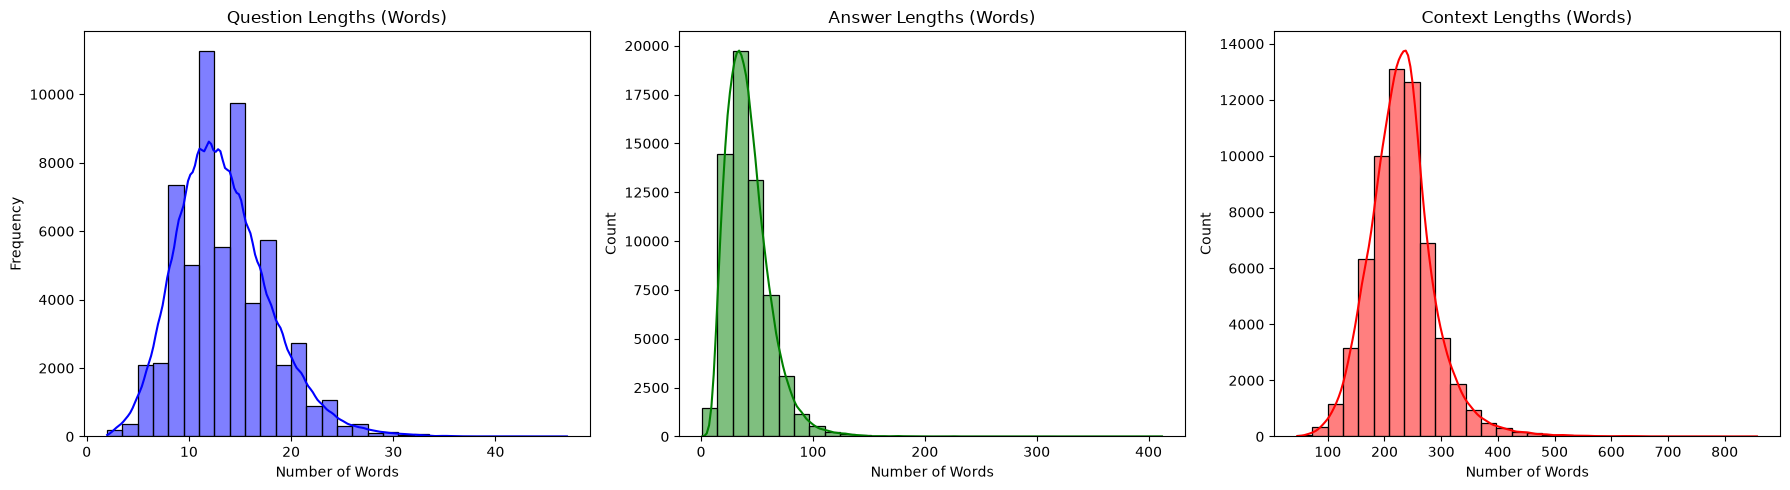

In [52]:
# Statistics
plt.figure(figsize=(18, 5))

# Plot 1: Question Length Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['question_word_count'], bins=30, kde=True, color='blue')
plt.title('Question Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
# Plot 2: Answer Length Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['answer_word_count'], bins=30, kde=True, color='green')
plt.title('Answer Lengths (Words)')
plt.xlabel('Number of Words')
# Plot 3: Context Length Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['context_word_count'], bins=30, kde=True, color='red')
plt.title('Context Lengths (Words)')
plt.xlabel('Number of Words')
plt.tight_layout()
plt.show()


In [53]:
print("Top 5 most common question type")
print(df['first_word'].value_counts().head(5))


print("\nTop 5 least common question type")
print(df['first_word'].value_counts().tail(5))

Top 5 most common question type
first_word
Is      10820
Does     9461
Do       4486
Can      4454
Are      3890
Name: count, dtype: int64

Top 5 least common question type
first_word
Jugular              1
Alcoholics'          1
Duodenojejunitis:    1
Pancreatitis         1
Diversion            1
Name: count, dtype: int64


## Bivariate & Multivariate Analysis 

                     question_word_count  context_word_count  \
question_word_count             1.000000            0.113691   
context_word_count              0.113691            1.000000   
answer_word_count               0.035288            0.146684   

                     answer_word_count  
question_word_count           0.035288  
context_word_count            0.146684  
answer_word_count             1.000000  


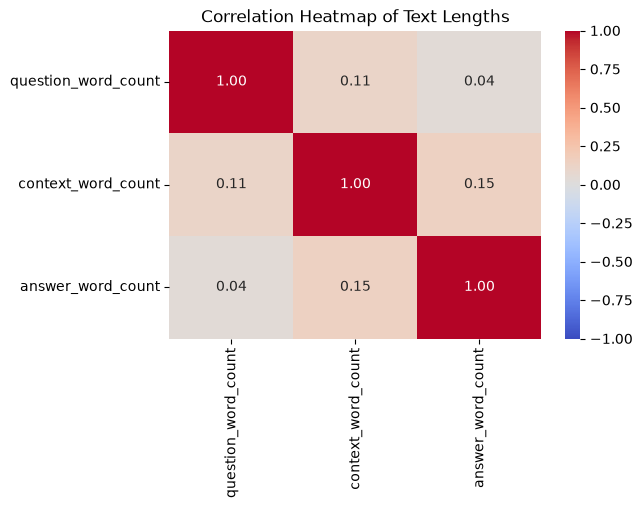

In [54]:
# Correlation Matrix
correlation_matrix = df[['question_word_count', 'context_word_count', 'answer_word_count']].corr()
print(correlation_matrix)
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Text Lengths')
plt.show()

## Lexical Overlap Analysis

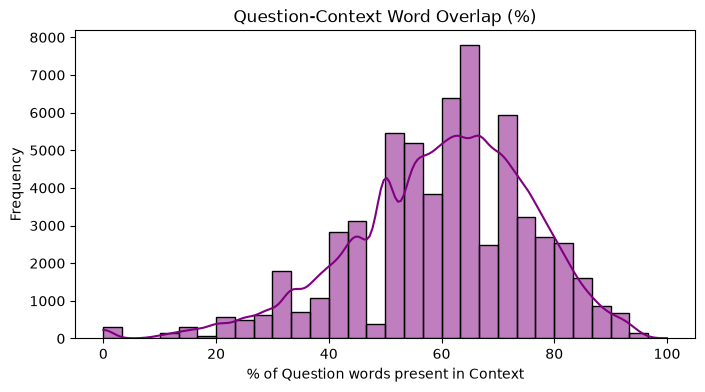

Average overlap: 60.0%


In [55]:
def calc_overlap(row):
    q_words = set(str(row['question']).lower().split())
    c_words = set(str(row['context']).lower().split())
    if not q_words:
        return 0
    # Percentage of question words found in context
    return len(q_words.intersection(c_words)) / len(q_words) * 100

df['q_c_overlap_pct'] = df.apply(calc_overlap, axis=1)

plt.figure(figsize=(8, 4))
sns.histplot(df['q_c_overlap_pct'], bins=30, kde=True, color='purple')
plt.title('Question-Context Word Overlap (%)')
plt.xlabel('% of Question words present in Context')
plt.ylabel('Frequency')
plt.show()

print(f"Average overlap: {df['q_c_overlap_pct'].mean():.1f}%")


## Clinical N-Gram Analysis

C:\Users\84913\AppData\Local\Temp\ipykernel_32776\2331898744.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x, palette="viridis")


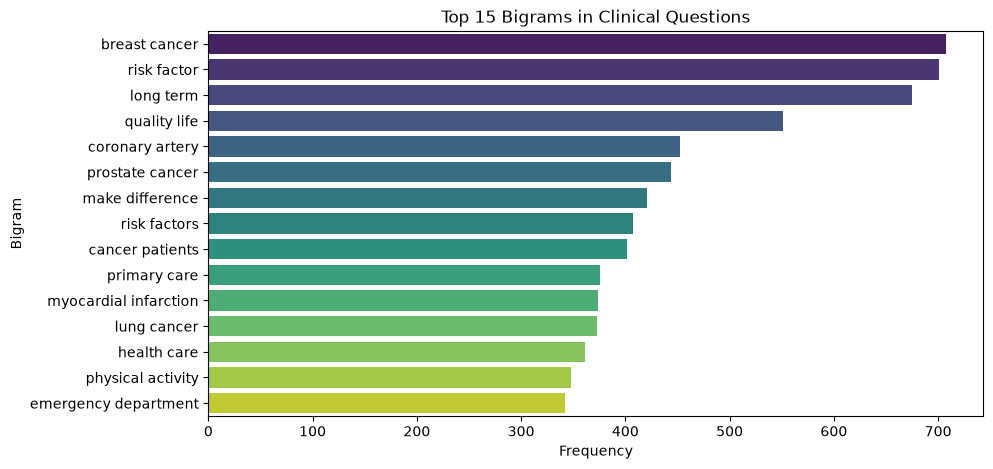

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None, ngram_range=(2,2)):
    # Removing common english stopwords to get purely clinical terms
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get top 15 Bigrams from Questions
top_bigrams = get_top_ngrams(df['question'].dropna(), n=15, ngram_range=(2,2))
x, y = map(list, zip(*top_bigrams))

plt.figure(figsize=(10, 5))
sns.barplot(x=y, y=x, palette="viridis")
plt.title('Top 15 Bigrams in Clinical Questions')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.show()


## Long Answer Polarity

C:\Users\84913\AppData\Local\Temp\ipykernel_32776\2441208476.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='proxy_label', order=['Likely Yes', 'Likely No', 'Likely Maybe / Mixed'], palette='Set2')


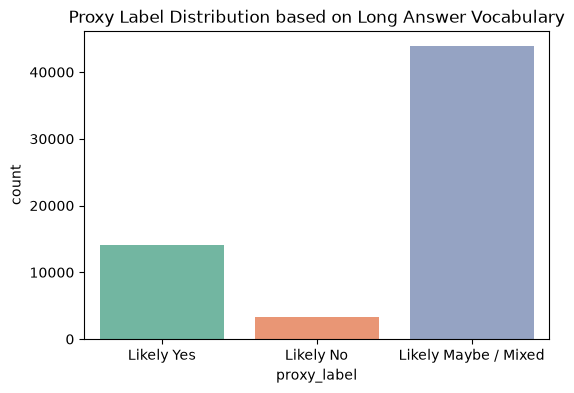

In [57]:
affirmative_words = ['significantly', 'effective', 'improved', 'associated with', 'beneficial', 'increased'] # May be modified
negative_words = ['no significant', 'ineffective', 'failed', 'not associated', 'adverse', 'did not'] # May be modified 

def classify_proxy_sentiment(text):
    text = str(text).lower()
    aff_count = sum(1 for w in affirmative_words if w in text)
    neg_count = sum(1 for w in negative_words if w in text)
    
    if aff_count > neg_count: return "Likely Yes"
    if neg_count > aff_count: return "Likely No"
    return "Likely Maybe / Mixed"

df['proxy_label'] = df['long_answer'].apply(classify_proxy_sentiment)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='proxy_label', order=['Likely Yes', 'Likely No', 'Likely Maybe / Mixed'], palette='Set2')
plt.title('Proxy Label Distribution based on Long Answer Vocabulary')
plt.show()


## Text Complexity

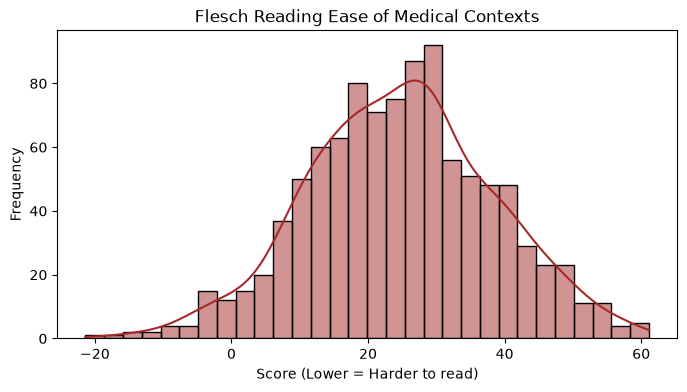

In [58]:
import textstat

# Sample 1000 rows to save time
sample_contexts = df['context'].dropna().sample(1000, random_state=42).astype(str)

# Calculate Flesch Reading Ease (lower score = harder to read)
# Standard medical text usually scores very low (0-30 = College Graduate level)
readability_scores = sample_contexts.apply(textstat.flesch_reading_ease)

plt.figure(figsize=(8, 4))
sns.histplot(readability_scores, bins=30, kde=True, color='brown')
plt.title('Flesch Reading Ease of Medical Contexts')
plt.xlabel('Score (Lower = Harder to read)')
plt.ylabel('Frequency')
plt.show()
